# Ecommerce Linear Regression Project

This notebook covers an end-to-end **Linear Regression** use case using ecommerce data.

## Objective
Predict **sales_amount** based on:
- categorical features
- numerical features
- basic preprocessing
- model training
- evaluation
- prediction on new input

---


## Task 1: Import libraries

Load all required Python libraries for:
- data handling
- preprocessing
- model building
- evaluation


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt


## Task 2: Read the ecommerce CSV file

In [3]:
df=pd.read_csv('ecommerce_regression_data.csv')
df

,product_category,customer_segment,payment_method,units_sold,discount_pct,ad_spend,customer_rating,returns_count,is_festival_season,sales_amount
0,Beauty,Regular,UPI,1,33,1832.03,4.1,0,1,1307.65
1,Electronics,Prime,Wallet,8,30,3331.92,3.9,2,1,2605.51
2,Home,Business,UPI,7,22,2531.15,4.5,2,0,2530.16
3,Electronics,Regular,UPI,5,36,2245.48,4.0,2,0,1719.26
4,Fashion,Regular,Card,5,5,2404.44,3.9,3,0,2131.67
...,...,...,...,...,...,...,...,...,...,...
995,Beauty,Regular,Card,7,0,2256.20,4.3,1,0,2399.03
996,Fashion,Prime,UPI,6,22,2287.48,3.7,0,0,2099.94
997,Home,Regular,Card,4,40,1839.05,4.1,0,0,1372.51
998,Fashion,Regular,Wallet,10,11,2936.58,3.3,2,0,2717.77


## Task 3: Check shape and column names

In [4]:
df.shape

(1000, 10)

In [5]:
df.columns

Index(['product_category', 'customer_segment', 'payment_method', 'units_sold',
       'discount_pct', 'ad_spend', 'customer_rating', 'returns_count',
       'is_festival_season', 'sales_amount'],
      dtype='str')

## Task 4: Explore dataset information and missing values

In [6]:
df.isna().any()

product_category       True
customer_segment       True
payment_method         True
units_sold            False
discount_pct          False
ad_spend               True
customer_rating        True
returns_count         False
is_festival_season    False
sales_amount          False
dtype: bool

In [12]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns
print(cat_cols)

Index(['product_category', 'customer_segment', 'payment_method'], dtype='str')


C:\Users\Sreemiraa.Tn\AppData\Local\Temp\ipykernel_25348\1312351319.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object", "category"]).columns


In [11]:
df['units_sold'] = df['units_sold'].fillna(df['units_sold'].mean())
df['discount_pct'] = df['discount_pct'].fillna(df['discount_pct'].mean())
df['returns_count'] = df['returns_count'].fillna(df['returns_count'].mean())
df['is_festival_season'] = df['is_festival_season'].fillna(df['is_festival_season'].mean())
df['sales_amount'] = df['sales_amount'].fillna(df['sales_amount'].mean())

In [13]:
df = pd.get_dummies(df, columns=["product_category","customer_segment","payment_method"])

bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

In [14]:
df

,units_sold,discount_pct,ad_spend,customer_rating,returns_count,is_festival_season,sales_amount,product_category_Beauty,product_category_Electronics,product_category_Fashion,product_category_Home,product_category_Sports,customer_segment_Business,customer_segment_Prime,customer_segment_Regular,payment_method_Card,payment_method_NetBanking,payment_method_UPI,payment_method_Wallet
0,1,33,1832.03,4.1,0,1,1307.65,1,0,0,0,0,0,0,1,0,0,1,0
1,8,30,3331.92,3.9,2,1,2605.51,0,1,0,0,0,0,1,0,0,0,0,1
2,7,22,2531.15,4.5,2,0,2530.16,0,0,0,1,0,1,0,0,0,0,1,0
3,5,36,2245.48,4.0,2,0,1719.26,0,1,0,0,0,0,0,1,0,0,1,0
4,5,5,2404.44,3.9,3,0,2131.67,0,0,1,0,0,0,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,7,0,2256.20,4.3,1,0,2399.03,1,0,0,0,0,0,0,1,1,0,0,0
996,6,22,2287.48,3.7,0,0,2099.94,0,0,1,0,0,0,1,0,0,0,1,0
997,4,40,1839.05,4.1,0,0,1372.51,0,0,0,1,0,0,0,1,1,0,0,0
998,10,11,2936.58,3.3,2,0,2717.77,0,0,1,0,0,0,0,1,0,0,0,1


## Task 5: Summary statistics

In [15]:
df.describe()

,units_sold,discount_pct,ad_spend,customer_rating,returns_count,is_festival_season,sales_amount,product_category_Beauty,product_category_Electronics,product_category_Fashion,product_category_Home,product_category_Sports,customer_segment_Business,customer_segment_Prime,customer_segment_Regular,payment_method_Card,payment_method_NetBanking,payment_method_UPI,payment_method_Wallet
count,1000.000000,1000.000000,985.000000,985.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.531000,19.874000,2430.335766,4.105076,1.438000,0.225000,2146.947540,0.146000,0.287000,0.218000,0.199000,0.140000,0.133000,0.23200,0.625000,0.237000,0.282000,0.217000,0.254000
std,2.878076,11.948678,911.384942,0.488771,1.124019,0.417791,552.016871,0.353283,0.452588,0.413094,0.399448,0.347161,0.339745,0.42232,0.484365,0.425455,0.450198,0.412409,0.435515
min,1.000000,0.000000,200.000000,2.600000,0.000000,0.000000,423.460000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,10.000000,1832.030000,3.800000,0.000000,0.000000,1764.660000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.000000,20.000000,2464.260000,4.100000,1.000000,0.000000,2141.540000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,8.000000,30.000000,3052.840000,4.500000,2.000000,0.000000,2550.967500,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000,1.000000,0.000000,1.000000
max,10.000000,40.000000,5122.820000,5.000000,3.000000,1.000000,3776.170000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000


## Task 6: Define target and input features

Target column:
- `sales_amount`

Input columns:
- all remaining columns


In [17]:
X = df.drop(columns='sales_amount')
y = df['sales_amount']


## Task 7: Build preprocessing pipelines

### For categorical columns
- fill missing values with most frequent value
- apply one-hot encoding

### For numerical columns
- fill missing values with median


In [32]:
df.isna().sum()

units_sold                      0
discount_pct                    0
ad_spend                        0
customer_rating                 0
returns_count                   0
is_festival_season              0
sales_amount                    0
product_category_Beauty         0
product_category_Electronics    0
product_category_Fashion        0
product_category_Home           0
product_category_Sports         0
customer_segment_Business       0
customer_segment_Prime          0
customer_segment_Regular        0
payment_method_Card             0
payment_method_NetBanking       0
payment_method_UPI              0
payment_method_Wallet           0
dtype: int64

In [31]:
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

## Task 8: Split data into train and test sets

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 18), (200, 18), (800,), (200,))

## Task 9: Create Linear Regression model pipeline

In [34]:

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
X.isna().sum()

units_sold                      0
discount_pct                    0
ad_spend                        0
customer_rating                 0
returns_count                   0
is_festival_season              0
product_category_Beauty         0
product_category_Electronics    0
product_category_Fashion        0
product_category_Home           0
product_category_Sports         0
customer_segment_Business       0
customer_segment_Prime          0
customer_segment_Regular        0
payment_method_Card             0
payment_method_NetBanking       0
payment_method_UPI              0
payment_method_Wallet           0
dtype: int64

## Task 10: Make predictions on test data

In [35]:
y_pred = model.predict(X_test)

## Task 11: Evaluate the model

In [36]:
print(f'Intercept: {model.intercept_}')
print(f'Coefficients: {model.coef_}')

Intercept: 734.9009009967322
Coefficients: [ 97.11626852 -18.08500936   0.41955503  72.61412054 -43.06415575
 130.57174993 -88.09548184  36.9914835  -71.55850749 -66.81808574
 -22.54824233  87.76660649  41.70496156 -31.26892157 -28.9015052
 -21.38188849  -5.03869591 -13.2577591 ]


In [37]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: {mae}')
print(f'R-squared: {r2}')

Mean Absolute Error: 97.96037213709114
R-squared: 0.945361265303003


## Task 12: Visualize Actual vs Predicted

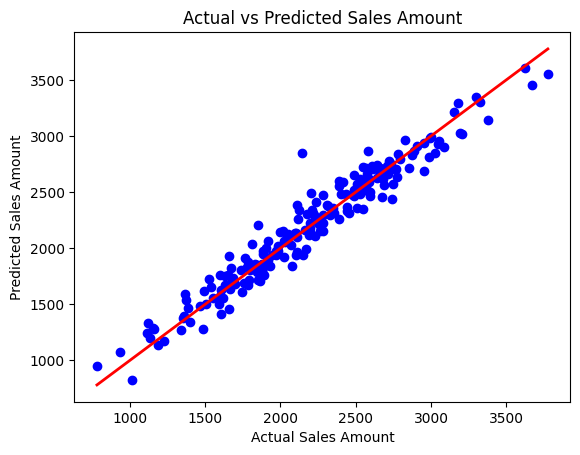

In [38]:
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.xlabel('Actual Sales Amount')
plt.ylabel('Predicted Sales Amount')
plt.title('Actual vs Predicted Sales Amount')
plt.show()

## Task 13: Residual analysis

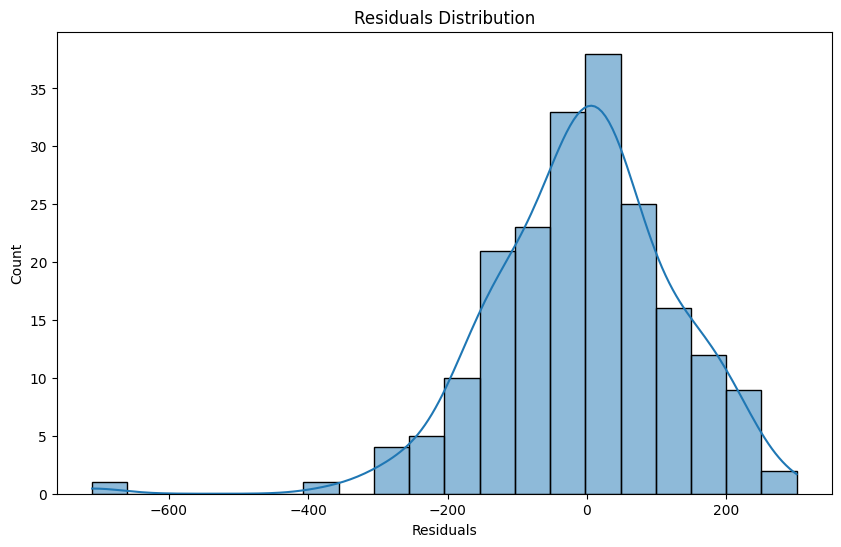

In [40]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(y_test - y_pred, kde=True)
plt.xlabel('Residuals')
plt.title('Residuals Distribution')
plt.show()


## Task 14: Predict sales for a new ecommerce record